In [1]:
# ==============================================================
# PIPELINE DE CLASSIFICATION BINAIRE MULTICRITÈRE - FIS GRATUITÉ
# ==============================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
%ls

Données_POC2024_2025_10122025.xls    fisprod_acorig.csv
PyTorchGPUM2Pro.ipynb                fisprod_valide.csv
VerificationService.php              pipeline.ipynb
best_model_mps.pt                    rapport_classification_torch.txt
chapipeline.ipynb                    statistiques_dataframe.txt


In [10]:
# 1️⃣ CHARGEMENT DU FICHIER ------------------------------------------------
#df1 = pd.read_csv("fisprodanonymeacorrigerv1.csv", sep=';', header=0)
#df2= pd.read_csv("fisprodanonymevalidev1.csv", sep=';', header=0)
#df = pd.concat([df1, df2], ignore_index=True, axis=0)

df1 = pd.read_csv("fisprod_acorig.csv", sep=',', header=0)
df2= pd.read_csv("fisprod_valide.csv", sep=',', header=0)
df = pd.concat([df1, df2], ignore_index=True, axis=0)

Avant SMOTE : [10000 10000]
Après SMOTE : [10000 10000]
===== RANDOM FOREST =====
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      3000
           1       0.96      0.98      0.97      3000

    accuracy                           0.97      6000
   macro avg       0.97      0.97      0.97      6000
weighted avg       0.97      0.97      0.97      6000



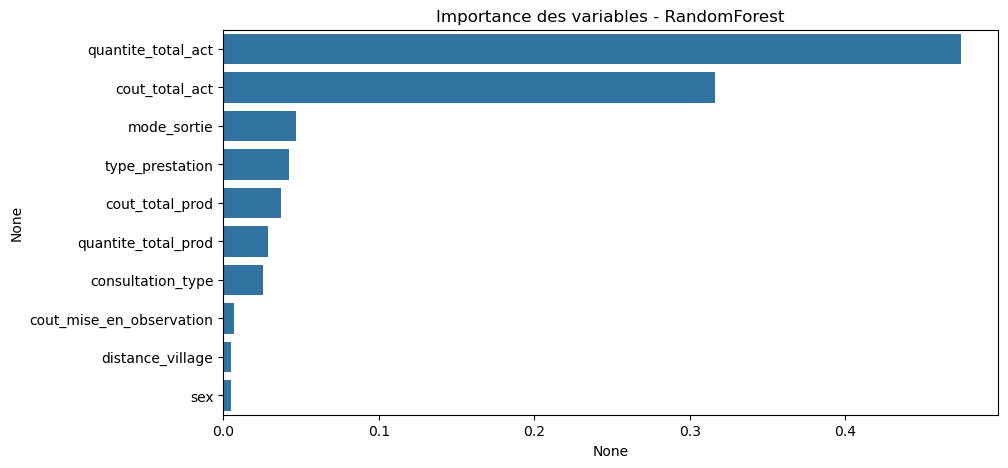

===== RÉGRESSION LOGISTIQUE =====
              precision    recall  f1-score   support

           0       0.96      0.84      0.90      3000
           1       0.86      0.96      0.91      3000

    accuracy                           0.90      6000
   macro avg       0.91      0.90      0.90      6000
weighted avg       0.91      0.90      0.90      6000



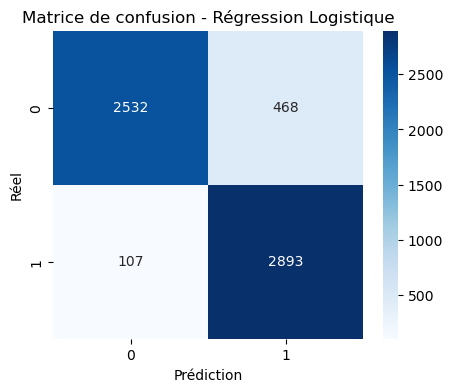

In [11]:
# 2️⃣ NETTOYAGE DE BASE ----------------------------------------------------
# Suppression des colonnes inutiles ou trop vides
colonnes_a_supprimer = [
    'tel', 'village', 'num_ordonance', 'user_id', 'is_delete', 'id_user_created',
    'id_user_updated', 'id_user_deleted', 'deleted_at', 'created_at', 'updated_at',
    'assurance', 'taux_assurance', 'structure_assurance', 'id_prescripteur',
    'id_gerant', 'id_village', 'id_api', 'mobile_app_version', 'is_contre_verification',
    'id_contre_verification', 'numero_assurance', 'id_assurance', 'slug_assurance',
    'id_motif', 'autre_motif', 'qualite_accompagnant'
]
df.drop(columns=[c for c in colonnes_a_supprimer if c in df.columns], inplace=True)

# Conversion des dates
for col in ['date_entree', 'date_sortie', 'date_verification']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Suppression des lignes sans statut de vérification
df = df.dropna(subset=['status_verification'])

# 3️⃣ ENCODAGE DE LA VARIABLE CIBLE ----------------------------------------
df['target'] = df['status_verification'].apply(lambda x: 1 if str(x).strip().lower() == 'a_corriger' else 0)

# 4️⃣ SELECTION DES VARIABLES EXPLICATIVES ---------------------------------
variables_numeriques = [
    'distance_village', 'quantite_total_prod', 'quantite_total_act',
    'cout_total_prod', 'cout_total_act', 'cout_total_ex',
    'cout_mise_en_observation', 'cout_evacuation', 'nbre_jours'
]

variables_categorielles = [
    'sex', 'consultation_type', 'type_prestation', 'type_observation', 'mode_sortie'
]

X = df[variables_numeriques + variables_categorielles].copy()
y = df['target']

# Gestion des valeurs manquantes
X[variables_numeriques] = X[variables_numeriques].fillna(0)
X[variables_categorielles] = X[variables_categorielles].fillna('inconnu')

# Encodage des catégories
for col in variables_categorielles:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5️⃣ EQUILIBRAGE DES CLASSES ----------------------------------------------
print("Avant SMOTE :", np.bincount(y))
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)
print("Après SMOTE :", np.bincount(y_res))

# 6️⃣ DIVISION EN TRAIN / TEST ---------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42, stratify=y_res
)

# 7️⃣ MODELE 1 : RANDOM FOREST ---------------------------------------------
rf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("===== RANDOM FOREST =====")
print(classification_report(y_test, y_pred_rf))

# Importance des variables
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=importances[:10], y=importances.index[:10])
plt.title("Importance des variables - RandomForest")
plt.show()

# 8️⃣ MODELE 2 : RÉGRESSION LOGISTIQUE ------------------------------------
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)

print("===== RÉGRESSION LOGISTIQUE =====")
print(classification_report(y_test, y_pred_lr))

# Matrice de confusion
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion - Régression Logistique")
plt.xlabel("Prédiction")
plt.ylabel("Réel")
plt.show()

# 9️⃣ SAUVEGARDE DU RAPPORT -----------------------------------------------
with open("rapport_classification.txt", "w", encoding="utf-8") as f:
    f.write("===== RANDOM FOREST =====\n")
    f.write(classification_report(y_test, y_pred_rf))
    f.write("\n\n===== RÉGRESSION LOGISTIQUE =====\n")
    f.write(classification_report(y_test, y_pred_lr))
